##Статус_файл


## Описание проекта и общий обзор данных

### Оглавление

### Описание проекта

Подразделение занимается разработкой конструкторских решений для нестандартных ремонтов и модификаций гражданских самолетов зарубежного производства, а также оказывает консультационные услуги по поддержанию уровня исправности самолетов и их систем, необходимого для выполнения безопасных полётов.

Идеальная ситуация: все самолеты исправны и выполняют рейсы по расписанию. В случае появления неисправности, описанной в руководстве по эксплуатации самолета, персонал авиакомпании или организации по техническому обслуживанию и ремонту самолётов (ТОиР) устраняет неисправность и выпускает самолет в рейс.

При возникновении неисправности, которая не описана в соответствующей документации, авиакомпания (заказчик) присылает в Подразделение запрос на разработку решения по устранению неисправности с подробным её описанием. При этом, в зависимости от расписания полётов, запрос получает статус AOG (Aircraft-on-the-ground) самолет уже должен вылетать, но не может из-за неисправности), СРОЧНЫЙ (самолет должен будет вылететь через несколько дней) или РУТИННЫЙ (самолет находится на обслуживании и должен быть готов к рейсу через 2-3 недели).

Таким образом, "на входе" подразделение получает запрос от заказчика, а "на выходе" - выдаёт решение, которое может быть ремонтом, модификацией или консультацией, в зависимости от характера неисправности.

Запросы от заказчиков за период с 01 июня 2023 года по 16 июня 2025 года собраны в файле Status_file_DRKR.xlsx.

__Цель проекта:__

Выявить закономерности, влияющие на:

- рост или снижение количества запросов;

- распределение количества затраченного на разработку решений времени.

__Данные:__

Для проекта использованы данные о поступивших в Подразделение запросах от заказчиков за период с 01 июня 2023 года по 16 июня 2025 года, собранные в файле Status_file_DRKR.xlsx.

__Задачи:__

В рамках данного проекта необходимо:

- Провести предварительную обработку данных и подготовить их к дальнейшему анализу;

- Проанализировать основные признаки запроса: тип запроса и его срочность, тип ВС и затронутая система, ожидаемая и фактическая дата выдачи решения по запросу.

- Выявить параметры, влияющие на рост или снижение количества запросов - сезонность, затронутая система, тип запроса;

- Выявить параметры заказа, влияющие на трудозатраты и изменение сроков его исполнения.

Набор данных включает следующие поля:
___________

`№` - порядковый номер запроса
;
`ID проекта` - номер проекта по разработке решения;

`Рев.` - ревизия проекта (внесение изменений в первоначальное решение);

`Тема` - название проекта;

`Dept` - отдел, ответственный за проект;

`Тип ВС` - тип воздушного судна;

`Рег. номер` - регистрационный номер самолёта;

`Категория запроса` - вид запроса по характеру повреждения (ремонт, модификация или консультация);

`Приоритет` - срочность запроса;

`Статус` - текущее состояние проекта;

`ФАП21` - организация по сертификации решения;

`SE` - специалист, ответственный за проект;

`ECD этапа` - _Estimated C Date - ожидаемая дата завершения этапа;_

`Date In` - дата поступления запроса;

`Due Date` - ориентировочная дата завершения проекта (выдачи решения);

`Авиакомпания` - заказчик;

`ATA` - номер системы по классификации АТА;

`Наличие акта` - отметка о принятии заказчиком выполненной работы (решения);

`HMR план` - планируемые трудозатраты (в часах);

`HMR факт` - фактические трудозатраты (в часах);

`Supplements` - наличие дополнительной технической документации;

`Complete Date` - реальная дата завершения проекта;

`Запрошенная Due` - дата завершения проекта, запрошенная заказчиком.


### План проекта

___________________________________

### Загрузка и общий обзор

In [ ]:
# загрузка библиотек
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#%config InlineBackend.figure_format = 'retina'
#matplotlib.style.use('ggplot')
#plt.rc('figure', figsize=(15, 6))

In [ ]:
#warnings.filterwarnings('ignore')
#sns.set_context("notebook")
pd.set_option('display.float_format', '{:.2f}'.format)

In [ ]:
# загрузка файла и общий обзор
data = pd.read_excel('/content/drive/MyDrive/DATA/Status_file.xlsx')

In [ ]:
data.head()

,№,ID проекта,Рев.,Тема,Dept,Тип ВС,Рег. номер,Категория запроса,Приоритет,Статус,...,Date In,Due Date,Авиакомпания,ATA,Наличие акта,HMR план,HMR факт,Supplements,Complete Date,Запрошенная Due
0,810,АФ-23-0620М,0,Применение нетекстильного напольного покрытия ...,NaN,B737,MULTI,Модификация,Routine (>5 days),Завершен,...,2023-07-04,2023-07-11,Аэрофлот,25,True,40.00,40.00,AIPC,2023-08-31,2023-07-11
1,811,АФ-23-0621М,0,Применение нетекстильного напольного покрытия ...,NaN,B777,MULTI,Модификация,Routine (>5 days),Завершен,...,2023-07-04,2023-07-11,Аэрофлот,25,False,40.00,40.00,AIPC,2023-09-01,2023-07-11
2,812,АФ-23-0622М,0,Применение комбинации текстильной застежки и д...,NaN,B737,RA-73108,Модификация,Routine (>5 days),Завершен,...,2023-07-05,2023-07-13,Аэрофлот,25,False,40.00,40.00,NaN,2023-07-14,2023-07-13
3,813,АФ-23-0623Р,0,Ремонт передней кромки правого внешнего закрыл...,NaN,A321,RA-73708,Ремонт,Routine (>5 days),Завершен,...,2023-07-01,2023-12-14,Аэрофлот,57,False,40.00,40.00,NaN,2023-12-15,2023-12-14
4,814,АФ-23-0624К,0,RUDDER - TRAPPED FLUID AROUND ALL HOSTING POINTS,NaN,A320,RA-73740,ПТР/Консультация,AOG (1-2 days),Завершен,...,2023-07-01,2023-07-07,Аэрофлот,55,False,2.00,2.00,NaN,2023-07-07,2023-07-03


#### Выявление пропусков в данных

In [ ]:
# выявление пропусков
display("Missing values:", data.isna().sum())

'Missing values:'

,0
№,0
ID проекта,0
Рев.,0
Тема,0
Dept,1838
Тип ВС,0
Рег. номер,320
Категория запроса,0
Приоритет,0
Статус,0


__Итого:__ Много пропусков в параметрах:

- `Dept` и `Supplement`: Параметры стали обязательными недавно, ранее не учитывались. Остаются как есть.

- `ECD этапа` и `ФАП21`: Неинформативные параметры, будут удалены.

Пропуски, которые нужно обработать:

- `Рег. номер`, `SE`, `HMR план`, `HMR факт`.

In [ ]:
# пропуски графически
#colors = ['#8E9A9D', '#F2AA80']
#sns.heatmap(data.isna(), yticklabels=False, cmap=colors, cbar=False);

In [ ]:
# уникальные значения
data.nunique()

,0
№,2315
ID проекта,2107
Рев.,6
Тема,1896
Dept,3
Тип ВС,17
Рег. номер,268
Категория запроса,4
Приоритет,3
Статус,4


In [ ]:
# проверка на дубликаты
data = data.drop_duplicates()
data.shape

(2315, 23)

__Итого:__ Дубликатов нет, но много пропусков в данных. Обратить внимание на заполнение статусного файла.

#### Общий обзор данных

In [ ]:
# общий обзор данных
data.describe(include='all')

,№,ID проекта,Рев.,Тема,Dept,Тип ВС,Рег. номер,Категория запроса,Приоритет,Статус,...,Date In,Due Date,Авиакомпания,ATA,Наличие акта,HMR план,HMR факт,Supplements,Complete Date,Запрошенная Due
count,2315.00,2315,2315.00,2315,477,2315,1995,2315,2315,2315,...,2315,2315,2315,2315.00,2315,2270.00,2259.00,255,2315,2315
unique,NaN,2107,NaN,1896,3,17,268,4,3,4,...,NaN,NaN,19,NaN,2,NaN,NaN,24,NaN,NaN
top,NaN,АФ-23-0688М,NaN,Ремонт хромового покрытия штока амортизатора п...,Отдел по вопросам конструкции,A320,MULTI,Ремонт,Routine (>5 days),Завершен,...,NaN,NaN,Аэрофлот,NaN,False,NaN,NaN,AIPC,NaN,NaN
freq,NaN,5,NaN,13,321,705,67,1463,1027,2067,...,NaN,NaN,2008,NaN,1528,NaN,NaN,82,NaN,NaN
mean,2183.99,NaN,0.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2024-05-19 13:46:40.691144704,2024-06-18 13:41:42.116630784,NaN,45.79,NaN,56.68,48.87,NaN,2024-06-18 04:55:27.861771008,2024-05-30 08:13:16.198704128
min,652.00,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2023-06-01 00:00:00,2023-06-05 00:00:00,NaN,0.00,NaN,0.00,1.00,NaN,2023-06-05 00:00:00,2023-06-05 00:00:00
25%,1431.50,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2023-12-07 00:00:00,2024-01-07 00:00:00,NaN,32.00,NaN,40.00,16.00,NaN,2024-01-07 00:00:00,2023-12-18 00:00:00
50%,2130.00,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2024-05-04 00:00:00,2024-05-31 00:00:00,NaN,53.00,NaN,40.00,40.00,NaN,2024-06-03 00:00:00,2024-05-16 00:00:00
75%,2947.50,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2024-11-02 00:00:00,2024-12-06 00:00:00,NaN,54.00,NaN,40.00,40.00,NaN,2024-12-06 00:00:00,2024-11-13 00:00:00
max,3827.00,NaN,5.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2025-06-14 00:00:00,2025-06-16 00:00:00,NaN,78.00,NaN,5500.00,4502.00,NaN,2025-06-15 00:00:00,2025-06-16 00:00:00


__Итого:__ 2315 запросов обработано за 2 года;

Чаще всего - ремонты, которыми занимается Отдел по вопросам конструкции.

13 проектов посвящены ремонту хромового покрытия штока амортизатора шасси.

Больше всего запросов для ВС типа А320.

Чаще всего запросы рутинные.

Средние планируемые трудозатраты - 56,7 часов, средние фактические - 48,9. 75% проектов укладываются в 40 часов. Есть экстремально трудозатратные проекты - до 4502 часов.

Чаще всего выпускается дополнение к IPC.

## Предобработка

#### Переименование столбцов и удаление неинформативных параметров.

In [ ]:
data.columns.tolist()

['№',
 'ID проекта',
 'Рев.',
 'Тема',
 'Dept',
 'Тип ВС',
 'Рег. номер',
 'Категория запроса',
 'Приоритет',
 'Статус',
 'ФАП21',
 'SE',
 'ECD этапа',
 'Date In',
 'Due Date',
 'Авиакомпания',
 'ATA',
 'Наличие акта',
 'HMR план',
 'HMR факт',
 'Supplements',
 'Complete Date',
 'Запрошенная Due']

In [ ]:
#удаление неинформативных параметров
data = data.drop(['Тема', '№',
                   'ФАП21',
                   'ECD этапа'],
                  axis=1)#

In [ ]:
data.columns.tolist()

['ID проекта',
 'Рев.',
 'Dept',
 'Тип ВС',
 'Рег. номер',
 'Категория запроса',
 'Приоритет',
 'Статус',
 'SE',
 'Date In',
 'Due Date',
 'Авиакомпания',
 'ATA',
 'Наличие акта',
 'HMR план',
 'HMR факт',
 'Supplements',
 'Complete Date',
 'Запрошенная Due']

In [ ]:
#переименование столбцов
data = data.rename(columns={'ID проекта': 'project_id', 'Рев.': 'rev', 'Dept': 'dept', 'Тип ВС': 'ac_type', 'Рег. номер': 'regN', 'ATA': 'ATA', 'Категория запроса': 'req_type','Приоритет': 'urgency','Статус': 'status','Date In': 'date_in', 'Due Date': 'due_date', 'Complete Date': 'complete_date',  'Авиакомпания': 'airlines', 'Запрошенная Due': 'requested_date', 'Наличие акта': 'final_act', 'HMR план': 'hours_plan', 'HMR факт': 'hours_fact', 'Supplements': 'supp'})#'Тема': 'Sub',
data.columns.tolist()

['project_id',
 'rev',
 'dept',
 'ac_type',
 'regN',
 'req_type',
 'urgency',
 'status',
 'SE',
 'date_in',
 'due_date',
 'airlines',
 'ATA',
 'final_act',
 'hours_plan',
 'hours_fact',
 'supp',
 'complete_date',
 'requested_date']

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2315 entries, 0 to 2314
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   project_id      2315 non-null   object        
 1   rev             2315 non-null   int64         
 2   dept            477 non-null    object        
 3   ac_type         2315 non-null   object        
 4   regN            1995 non-null   object        
 5   req_type        2315 non-null   object        
 6   urgency         2315 non-null   object        
 7   status          2315 non-null   object        
 8   SE              2313 non-null   object        
 9   date_in         2315 non-null   datetime64[ns]
 10  due_date        2315 non-null   datetime64[ns]
 11  airlines        2315 non-null   object        
 12  ATA             2315 non-null   int64         
 13  final_act       2315 non-null   bool          
 14  hours_plan      2270 non-null   float64       
 15  hour

#### Изменение типа файлов.

ATA - в `object`.

In [ ]:
data.ATA.unique()

array([25, 57, 55, 53, 21, 28, 34, 54, 51, 32, 23, 30, 56, 20, 24, 38, 27,
       72, 44, 33, 36, 52, 78, 35,  0,  5, 22, 31, 49, 11, 71, 46, 26, 29,
       73, 45, 10, 47])

In [ ]:
data['ATA'] = data['ATA'].astype('object')

In [ ]:
data.ATA.unique()

array([25, 57, 55, 53, 21, 28, 34, 54, 51, 32, 23, 30, 56, 20, 24, 38, 27,
       72, 44, 33, 36, 52, 78, 35, 0, 5, 22, 31, 49, 11, 71, 46, 26, 29,
       73, 45, 10, 47], dtype=object)

#### Обработка пропусков

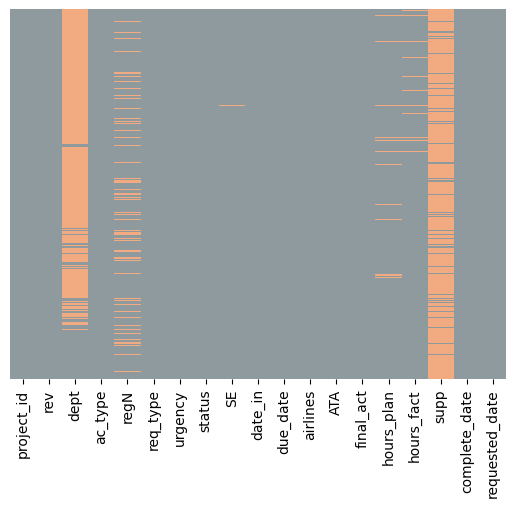

In [ ]:
colors = ['#8E9A9D', '#F2AA80']
sns.heatmap(data.isna(), yticklabels=False, cmap=colors, cbar=False);

In [ ]:
data_se = data[data['SE'].isna()]
data_se
#пропуски в SE связаны с отмененными запросами

,project_id,rev,dept,ac_type,regN,req_type,urgency,status,SE,date_in,due_date,airlines,ATA,final_act,hours_plan,hours_fact,supp,complete_date,requested_date
555,АФ-23-1134М,0,ОМиПИФ,B737,MULTI,Модификация,Routine (>5 days),Отменен,NaN,2023-11-29,2023-12-22,Норд Стар,52,False,500.00,2.00,NaN,2023-12-22,2023-12-08
604,АФ-23-1194М,0,NaN,A350,RA-73157,Модификация,Critical (2-5 days),Отменен,NaN,2023-12-15,2023-12-21,Аэрофлот,24,False,NaN,NaN,NaN,2023-12-18,2023-12-21


In [ ]:
data_hp = data[data['hours_plan'].isna()]
data_hp
#пропуски в плановых часах связаны с отмененными запросами

,project_id,rev,dept,ac_type,regN,req_type,urgency,status,SE,date_in,due_date,airlines,ATA,final_act,hours_plan,hours_fact,supp,complete_date,requested_date
7,АФ-23-0625Р,0,NaN,A320,RA-73767,Ремонт,Critical (2-5 days),Отменен,Горбачев А,2023-07-05,2023-07-12,Аэрофлот,53,False,NaN,NaN,NaN,2023-07-05,2023-07-09
40,АФ-23-1179Р,0,NaN,B777,RA-73292,Ремонт,Critical (2-5 days),Отменен,Горбачев А,2023-12-14,2023-12-21,Россия,54,False,NaN,NaN,NaN,2023-12-19,2023-12-21
87,АФ-23-0563К,0,NaN,B737,RA-73211,ПТР/Консультация,AOG (1-2 days),Отменен,Семенов Д,2023-06-22,2023-06-25,Россия,53,False,NaN,NaN,NaN,2023-06-27,2023-06-25
104,АФ-23-0583Р,0,NaN,A320,RA-73767,Ремонт,Critical (2-5 days),Отменен,Горбачев А,2023-06-28,2023-07-12,Аэрофлот,53,False,NaN,NaN,NaN,2023-07-05,2023-06-29
125,АФ-23-0604Р,0,NaN,A320,RA-73767,Ремонт,Critical (2-5 days),Отменен,Горбачев А,2023-06-30,2023-07-12,Аэрофлот,53,False,NaN,NaN,NaN,2023-07-05,2023-07-05
203,АФ-23-0706Р,0,NaN,A330,RA-73848,Ремонт,Routine (>5 days),Отменен,Наумов М,2023-08-08,2023-08-21,Аэрофлот,54,False,NaN,NaN,NaN,2023-08-08,2023-08-21
385,АФ-23-0948Р,0,NaN,A330,RA-73687,Ремонт,Routine (>5 days),Отменен,Работнев А,2023-10-11,2023-11-25,iFly,32,False,NaN,NaN,NaN,2023-11-30,2023-11-25
554,АФ-23-1133Р,0,NaN,B777,RA-73277,Ремонт,Routine (>5 days),Отменен,Святский А,2023-12-01,2023-12-08,Россия,54,False,NaN,NaN,NaN,2023-12-08,2023-12-08
564,АФ-23-1142Р,0,NaN,B737,RA-73122,Ремонт,Routine (>5 days),Отменен,Горбачев А,2023-12-06,2024-04-04,Аэрофлот,52,False,NaN,NaN,NaN,2024-02-20,2023-12-15
565,АФ-23-1143Р,0,NaN,B737,RA-73296,Ремонт,Routine (>5 days),Отменен,Горбачев А,2023-12-05,2023-12-22,Победа,57,False,NaN,NaN,NaN,2023-12-25,2023-12-15


In [ ]:
data_hf = data[data['hours_fact'].isna()]
data_hf
#пропуски в плановых часах связаны с отмененными запросами

,project_id,rev,dept,ac_type,regN,req_type,urgency,status,SE,date_in,due_date,airlines,ATA,final_act,hours_plan,hours_fact,supp,complete_date,requested_date
7,АФ-23-0625Р,0,NaN,A320,RA-73767,Ремонт,Critical (2-5 days),Отменен,Горбачев А,2023-07-05,2023-07-12,Аэрофлот,53,False,NaN,NaN,NaN,2023-07-05,2023-07-09
9,АФ-23-0517Р,1,NaN,A321,RA-73716,Ремонт,Critical (2-5 days),Отменен,Наумов М,2023-06-13,2023-07-07,Аэрофлот,53,False,8.00,NaN,NaN,2023-07-06,2023-07-06
17,АФ-23-0732К,0,NaN,A330,NaN,ПТР/Консультация,Routine (>5 days),Отменен,Виштак С,2023-08-16,2023-10-27,iFly,25,False,40.00,NaN,NaN,2023-10-09,2023-10-10
40,АФ-23-1179Р,0,NaN,B777,RA-73292,Ремонт,Critical (2-5 days),Отменен,Горбачев А,2023-12-14,2023-12-21,Россия,54,False,NaN,NaN,NaN,2023-12-19,2023-12-21
87,АФ-23-0563К,0,NaN,B737,RA-73211,ПТР/Консультация,AOG (1-2 days),Отменен,Семенов Д,2023-06-22,2023-06-25,Россия,53,False,NaN,NaN,NaN,2023-06-27,2023-06-25
93,АФ-23-0571К,0,NaN,A320,RA-73767,ПТР/Консультация,Critical (2-5 days),Отменен,Семенов Д,2023-06-26,2023-06-26,Аэрофлот,53,False,40.00,NaN,NaN,2023-07-05,2023-06-26
104,АФ-23-0583Р,0,NaN,A320,RA-73767,Ремонт,Critical (2-5 days),Отменен,Горбачев А,2023-06-28,2023-07-12,Аэрофлот,53,False,NaN,NaN,NaN,2023-07-05,2023-06-29
106,АФ-23-0585Р,0,NaN,B737,RA-73113,Ремонт,Routine (>5 days),Отменен,Наумов М,2023-06-28,2023-07-14,Аэрофлот,54,False,40.00,NaN,NaN,2023-07-05,2023-07-11
125,АФ-23-0604Р,0,NaN,A320,RA-73767,Ремонт,Critical (2-5 days),Отменен,Горбачев А,2023-06-30,2023-07-12,Аэрофлот,53,False,NaN,NaN,NaN,2023-07-05,2023-07-05
151,АФ-23-0651М,0,NaN,B737,NaN,Модификация,Routine (>5 days),Отменен,Сидоров Д,2023-07-12,2024-01-15,UTair,23,False,80.00,NaN,NaN,2024-01-15,2024-01-15


In [ ]:
data_rn = data[data['regN'].isna()]
data_rn
#пропуски в regN - за редким исключением можно заменить на MULTI

,project_id,rev,dept,ac_type,regN,req_type,urgency,status,SE,date_in,due_date,airlines,ATA,final_act,hours_plan,hours_fact,supp,complete_date,requested_date
17,АФ-23-0732К,0,NaN,A330,NaN,ПТР/Консультация,Routine (>5 days),Отменен,Виштак С,2023-08-16,2023-10-27,iFly,25,False,40.00,NaN,NaN,2023-10-09,2023-10-10
35,АФ-23-1174И,0,Отдел по вопросам систем ВС,SSJ,NaN,Исследование,Routine (>5 days),Завершен,Работнев А,2023-11-30,2025-03-28,Аэрофлот,32,False,160.00,320.00,NaN,2025-03-21,2024-12-13
45,АФ-23-0497К,0,NaN,B737,NaN,ПТР/Консультация,Critical (2-5 days),Завершен,Семенов Д,2023-06-05,2023-06-05,Аэрофлот,54,False,2.00,2.00,NaN,2023-06-05,2023-06-05
47,АФ-23-0502М,0,NaN,B737,NaN,Модификация,Routine (>5 days),Завершен,Кунец А,2023-06-06,2023-06-23,Россия,23,True,40.00,40.00,NaN,2023-06-23,2023-06-23
54,АФ-23-0053М,1,NaN,B737,NaN,Модификация,Routine (>5 days),Завершен,Мун Е,2023-06-05,2023-06-06,Аэрофлот,34,True,16.00,16.00,NaN,2023-06-14,2023-06-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2230,АФ-25-0437М,0,ОМиПИФ,A330,NaN,Модификация,Routine (>5 days),Завершен,Шатров С,2025-04-18,2025-04-30,Аэрофлот,25,False,120.00,120.00,AMM; CMM,2025-04-30,2025-04-22
2270,АФ-25-0490Р,0,Отдел по вопросам конструкции,B737,NaN,Ремонт,Routine (>5 days),Завершен,Горбачев А,2025-05-02,2025-05-23,БелАвиа,53,False,40.00,40.00,NaN,2025-05-23,2025-05-05
2300,АФ-25-0542М,0,Отдел по вопросам конструкции,B777,NaN,Модификация,Routine (>5 days),Сертификация,Горбачев А,2025-05-23,2025-06-16,Аэрофлот,57,False,120.00,80.00,SRM,2025-06-11,2025-06-16
2305,АФ-25-0551К,0,Отдел по вопросам конструкции,A320,NaN,ПТР/Консультация,Routine (>5 days),Завершен,Баранов Г,2025-05-31,2025-06-09,Аэрофлот,54,False,40.00,6.00,NaN,2025-06-05,2025-06-09


__Итого:__ про пропуски:

`dept` и `supp`- недавно начали регулярно вносить, оставить как есть;

`regN`- заменить на MULTI;

`SE` - заменить на unknown;

`hours_plan`, `hours_fact`- оставить как есть, т.к. пропуски связаны с отмененными работами.


#### Проверка на неявные дубликаты

In [ ]:
data.status.unique()

array(['Завершен', 'Отменен', 'Утвержден', 'Сертификация'], dtype=object)

In [ ]:
data.ac_type.unique()

array(['B737', 'B777', 'A321', 'A320', 'A330', 'SSJ', 'A350', 'B747',
       'E170', 'E190', 'ATR42', 'ATR72', 'B767', 'FLEET', 'A319', 'FLCN',
       'B757'], dtype=object)

In [ ]:
data.regN.unique()

array(['MULTI', 'RA-73108', 'RA-73708', 'RA-73740', 'RA-73767',
       'RA-73716', 'RA-73784', 'RA-73782', 'RA-73485', 'RA-73484',
       'RA-73111', 'RA-73211', nan, 'RA-73783', 'RA-73099', 'RA-73725',
       'RA-73786', 'RA-73176', 'RA-73771', 'RA-73121', 'RA-73126',
       'RA-73714', 'RA-73773', 'RA-73292', 'RA-73744', 'RA-73707',
       'RA-73165', 'RA-73724', 'RA-73151', 'RA-73739', 'RA-73290',
       'RA-73113', 'RA-73138', 'RA-73294', 'RA-73788', 'RA-73147',
       'RA-73134', 'RA-73150', 'RA-73322', 'RA-73171', 'RA-73105',
       'RA-73769', 'RA-73152', 'RA-73110', 'RA-73100', 'Ra-73485',
       'RA-73282', 'RA-73764', 'RA-73722', 'RA-73728', 'RA-73122',
       'RA-73703', 'RA-73706', 'RA-73284', 'RA-73123', 'RA-73112',
       'Multi', 'RA-73154', 'MULTI\n73126', 'RA-73848', 'RA-73160',
       'RA-73687', 'RA-73107', 'RA-73140', 'RA-73155', 'RA-73139',
       'RA-73723', 'RA-73104', 'RA-73770', 'RA-73218', 'RA-73109',
       'RA-73709', 'RA-73765', 'RA-73169', 'RA-73755', 'RA-

In [ ]:
#неявные дубликаты в параметре 'regN'
data['regN'] = data['regN'].replace(['Multi', 'MULTI\n73126', 'All'], 'MULTI')

In [ ]:
#заполнение пропусков в параметре 'regN'
data['regN'] = data['regN'].replace(np.nan, 'MULTI')

In [ ]:
data.regN.unique()

array(['MULTI', 'RA-73108', 'RA-73708', 'RA-73740', 'RA-73767',
       'RA-73716', 'RA-73784', 'RA-73782', 'RA-73485', 'RA-73484',
       'RA-73111', 'RA-73211', 'RA-73783', 'RA-73099', 'RA-73725',
       'RA-73786', 'RA-73176', 'RA-73771', 'RA-73121', 'RA-73126',
       'RA-73714', 'RA-73773', 'RA-73292', 'RA-73744', 'RA-73707',
       'RA-73165', 'RA-73724', 'RA-73151', 'RA-73739', 'RA-73290',
       'RA-73113', 'RA-73138', 'RA-73294', 'RA-73788', 'RA-73147',
       'RA-73134', 'RA-73150', 'RA-73322', 'RA-73171', 'RA-73105',
       'RA-73769', 'RA-73152', 'RA-73110', 'RA-73100', 'Ra-73485',
       'RA-73282', 'RA-73764', 'RA-73722', 'RA-73728', 'RA-73122',
       'RA-73703', 'RA-73706', 'RA-73284', 'RA-73123', 'RA-73112',
       'RA-73154', 'RA-73848', 'RA-73160', 'RA-73687', 'RA-73107',
       'RA-73140', 'RA-73155', 'RA-73139', 'RA-73723', 'RA-73104',
       'RA-73770', 'RA-73218', 'RA-73109', 'RA-73709', 'RA-73765',
       'RA-73169', 'RA-73755', 'RA-73135', 'RA-73745', 'RA-73240'

In [ ]:
#заполнение пропусков в параметре 'SE'
data['SE'] = data['SE'].replace(np.nan, 'unknown')

In [ ]:
data.airlines.unique()

array(['Аэрофлот', 'Россия', 'iFly', 'Победа', 'NordWind', 'UTair',
       'Сибирь', 'Икар', 'Норд Стар', 'БелАвиа', 'Ural Airlines',
       'СмартАвиа', 'СЛО Россия', 'Северо-Запад', 'АВИАСТАР-ТУ',
       'КрасАвиа', 'Red Wings', 'ГазпромАвиа', 'Арт Авиа'], dtype=object)

In [ ]:
data.dept.unique()

array([nan, 'Отдел по вопросам систем ВС',
       'Отдел по вопросам конструкции', 'ОМиПИФ'], dtype=object)

In [ ]:
data.supp.unique()

array(['AIPC', nan, 'AMM', 'AMM; Инструкция по ПЛГ', 'Тех. заключение',
       'AFM', 'CMM', 'AIPC; AMM', 'AMM; SRM', 'AIPC; CMM',
       'AIPC; AMM; FCOM/FAM; Инструкция по ПЛГ',
       'AFM; AIPC; FCOM/FAM; MMEL', 'SRM', 'FCOM/FAM', 'AIPC; AMM; CMM',
       'MMEL', 'Информ. письмо', 'AIPC; AMM; WBM',
       'AIPC; CMM; Инструкция по ПЛГ', 'CCOM/FAM; CMM',
       'AIPC; AMM; FCOM/FAM', 'Инструкция по ПЛГ', 'AMM; CMM',
       'AMM; Тех. заключение', 'AFM; FCOM/FAM'], dtype=object)

In [ ]:
data.req_type.unique()

array(['Модификация', 'Ремонт', 'ПТР/Консультация', 'Исследование'],
      dtype=object)

In [ ]:
data.urgency.unique()

array(['Routine (>5 days)', 'AOG (1-2 days)', 'Critical (2-5 days)'],
      dtype=object)

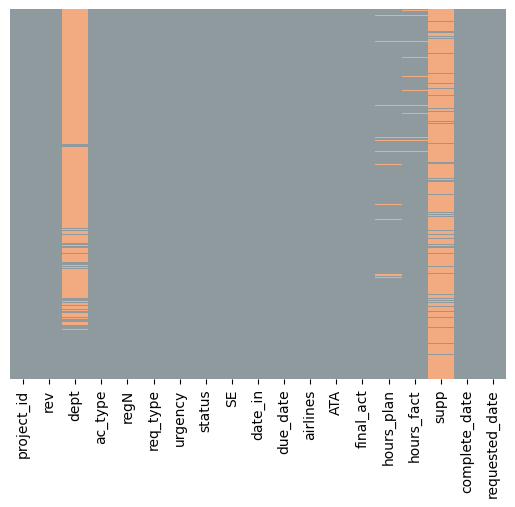

In [ ]:
colors = ['#8E9A9D', '#F2AA80']
sns.heatmap(data.isna(), yticklabels=False, cmap=colors, cbar=False);

In [ ]:
data['hours_plan'].describe()

,hours_plan
count,2270.00
mean,56.68
std,172.25
min,0.00
25%,40.00
50%,40.00
75%,40.00
max,5500.00


In [ ]:
data['hours_fact'].describe()

,hours_fact
count,2259.00
mean,48.87
std,150.26
min,1.00
25%,16.00
50%,40.00
75%,40.00
max,4502.00


In [ ]:
#анонимизация столбца с фамилиями
data['se_id'], uniques = pd.factorize(data['SE'])
data.head()

,project_id,rev,dept,ac_type,regN,req_type,urgency,status,SE,date_in,due_date,airlines,ATA,final_act,hours_plan,hours_fact,supp,complete_date,requested_date,se_id
0,АФ-23-0620М,0,NaN,B737,MULTI,Модификация,Routine (>5 days),Завершен,Сулимов А,2023-07-04,2023-07-11,Аэрофлот,25,True,40.00,40.00,AIPC,2023-08-31,2023-07-11,0
1,АФ-23-0621М,0,NaN,B777,MULTI,Модификация,Routine (>5 days),Завершен,Кирьянова Е,2023-07-04,2023-07-11,Аэрофлот,25,False,40.00,40.00,AIPC,2023-09-01,2023-07-11,1
2,АФ-23-0622М,0,NaN,B737,RA-73108,Модификация,Routine (>5 days),Завершен,Сулимов А,2023-07-05,2023-07-13,Аэрофлот,25,False,40.00,40.00,NaN,2023-07-14,2023-07-13,0
3,АФ-23-0623Р,0,NaN,A321,RA-73708,Ремонт,Routine (>5 days),Завершен,Баранов Г; Наумов М,2023-07-01,2023-12-14,Аэрофлот,57,False,40.00,40.00,NaN,2023-12-15,2023-12-14,2
4,АФ-23-0624К,0,NaN,A320,RA-73740,ПТР/Консультация,AOG (1-2 days),Завершен,Семенов Д,2023-07-01,2023-07-07,Аэрофлот,55,False,2.00,2.00,NaN,2023-07-07,2023-07-03,3


In [ ]:
#data.SE.unique()

In [ ]:
data['SE'].value_counts().head()

,count
SE,
Святский А,388
Горбачев А,270
Семенов Д,263
Баранов Г,261
Наумов М,154


In [ ]:
data.se_id.unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73])

In [ ]:
#data.regN.unique()

In [ ]:
#анонимизация номеров самолетов
data['ac_id'], uniques = pd.factorize(data['regN'])
data.head()

,project_id,rev,dept,ac_type,regN,req_type,urgency,status,SE,date_in,...,airlines,ATA,final_act,hours_plan,hours_fact,supp,complete_date,requested_date,se_id,ac_id
0,АФ-23-0620М,0,NaN,B737,MULTI,Модификация,Routine (>5 days),Завершен,Сулимов А,2023-07-04,...,Аэрофлот,25,True,40.00,40.00,AIPC,2023-08-31,2023-07-11,0,0
1,АФ-23-0621М,0,NaN,B777,MULTI,Модификация,Routine (>5 days),Завершен,Кирьянова Е,2023-07-04,...,Аэрофлот,25,False,40.00,40.00,AIPC,2023-09-01,2023-07-11,1,0
2,АФ-23-0622М,0,NaN,B737,RA-73108,Модификация,Routine (>5 days),Завершен,Сулимов А,2023-07-05,...,Аэрофлот,25,False,40.00,40.00,NaN,2023-07-14,2023-07-13,0,1
3,АФ-23-0623Р,0,NaN,A321,RA-73708,Ремонт,Routine (>5 days),Завершен,Баранов Г; Наумов М,2023-07-01,...,Аэрофлот,57,False,40.00,40.00,NaN,2023-12-15,2023-12-14,2,2
4,АФ-23-0624К,0,NaN,A320,RA-73740,ПТР/Консультация,AOG (1-2 days),Завершен,Семенов Д,2023-07-01,...,Аэрофлот,55,False,2.00,2.00,NaN,2023-07-07,2023-07-03,3,3


In [ ]:
#отложенная дата - разница между запрошенной датой и фактической датой окончания
data['postpone'] = data['complete_date'] - data['requested_date']
data['postpone'].dt.days
data['postpone'] = data['postpone'].dt.days.astype('int64')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2315 entries, 0 to 2314
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   project_id      2315 non-null   object        
 1   rev             2315 non-null   int64         
 2   dept            477 non-null    object        
 3   ac_type         2315 non-null   object        
 4   regN            2315 non-null   object        
 5   req_type        2315 non-null   object        
 6   urgency         2315 non-null   object        
 7   status          2315 non-null   object        
 8   SE              2315 non-null   object        
 9   date_in         2315 non-null   datetime64[ns]
 10  due_date        2315 non-null   datetime64[ns]
 11  airlines        2315 non-null   object        
 12  ATA             2315 non-null   object        
 13  final_act       2315 non-null   bool          
 14  hours_plan      2270 non-null   float64       
 15  hour

In [ ]:
data[['se_id', 'ac_id']] = data[['se_id', 'ac_id']].astype('object')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2315 entries, 0 to 2314
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   project_id      2315 non-null   object        
 1   rev             2315 non-null   int64         
 2   dept            477 non-null    object        
 3   ac_type         2315 non-null   object        
 4   regN            2315 non-null   object        
 5   req_type        2315 non-null   object        
 6   urgency         2315 non-null   object        
 7   status          2315 non-null   object        
 8   SE              2315 non-null   object        
 9   date_in         2315 non-null   datetime64[ns]
 10  due_date        2315 non-null   datetime64[ns]
 11  airlines        2315 non-null   object        
 12  ATA             2315 non-null   object        
 13  final_act       2315 non-null   bool          
 14  hours_plan      2270 non-null   float64       
 15  hour

In [ ]:
#data = data.drop(['SE'],
                  #axis=1)
#data.info()

### Итого

__Итого:__ В процессе предобработки:

- проведена проверка на дубликаты: явных дубликатов нет, неявные в параметре regN обработаны;

- проверка пропущенных значений:

  - `dept`и `supp`- регулярно начали вносить недавно, оставил как есть;

  - `regN`- неявные дубликаты заменил на MULTI;

  - `hours_plan`, `hours_fact`- оставил как есть, т.к. пропуски связаны с отмененными работами;

- удалены неинформативные столбцы, остальные переименованы (лат и нижний регистр);

- добавлен параметр `postpone` - разница между запрошенной заказчиком датой завершения работ и фактической датой в днях;

- проведена анонимизация персональных данных сотрудников и рег. номеров ВС.

In [ ]:
data.to_excel("Status2.xlsx", index=True)

____________________

## Исследовательский анализ

1. Разница между date in, requested date и complete date, due date.

3. Сумма потраченных часов на отмененные работы.-ХXXX

4. Доли запросов по типу. -XXXX

5. Доли запросов по срочности. -XXXX

6. Вывести из даты годы и месяцы, посчитать количество по статусам по месяцам.

7. Доли по типам и количество по месяцам.

8. Посчитать лидеров по запросам.

9. Доли компаний (кроме группы АФЛ).

10. Удельное количество запросов (в среднем на одно ВС данного типа - поделить на количество ВС в парке).

In [ ]:
# процент полученных Актов по типам завершенных запросов
#df_finished = data.query('status == "Завершен"').pivot_table(index='req_type',
                                                            #values='final_act',
                                                            #aggfunc=['count', 'sum', 'mean']).sort_values('req_type', ascending=False)
#df_finished.columns=["Завершенные запросы", "Получен FinalAct", "% (х100)"]
#df_finished

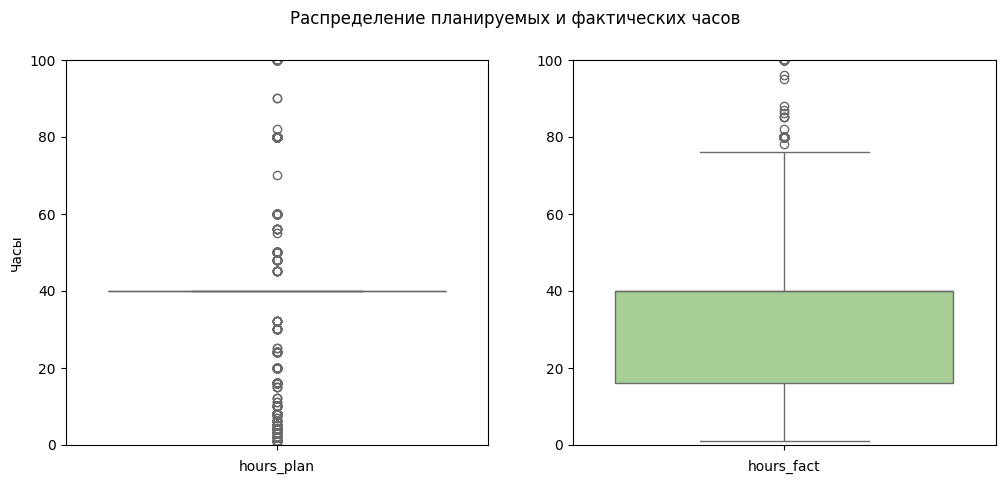

In [ ]:
# распределение планируемых и фактических часов
fig = plt.figure(figsize=(12, 5))
fig.suptitle('Распределение планируемых и фактических часов', size=(12))
color='#A3D98B'

ax1 = fig.add_subplot(1, 2, 1)
ax1 = sns.boxplot(y=data.hours_plan, color=color)
ax1.set_ylim(0, 100)
ax1.set_xlabel('hours_plan')
ax1.set_ylabel('Часы')

ax2 = fig.add_subplot(1, 2, 2)
ax2 = sns.boxplot(y=data.hours_fact, color=color)
ax2.set_ylim(0, 100)
ax2.set_xlabel('hours_fact')
ax2.set_ylabel('');

In [ ]:
# АК кроме группы Аэрофлот
data_airlines = data.query('airlines not in ["Аэрофлот", "Россия", "Победа"]').groupby('airlines')['project_id'].agg('count').sort_values(ascending=False).head(10)
data_airlines

,project_id
airlines,
Сибирь,25
UTair,14
ГазпромАвиа,9
iFly,9
СмартАвиа,8
Ural Airlines,6
Норд Стар,5
Северо-Запад,5
Икар,4


<Axes: xlabel='date_in', ylabel='postpone'>

<Figure size 2000x600 with 0 Axes>

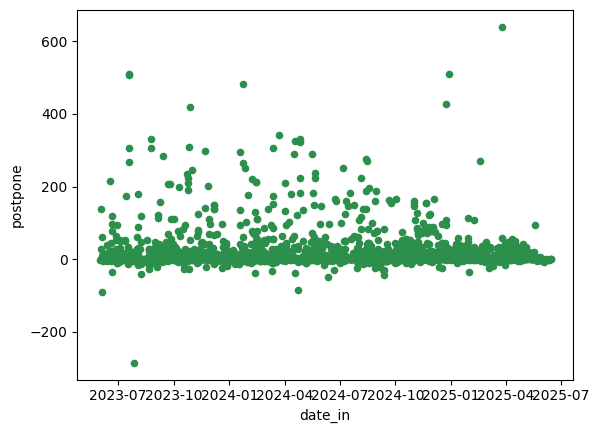

In [ ]:
#изменение отложенной даты за 2 года
fig = plt.figure(figsize=(20, 6))
data.plot(kind='scatter', x='date_in', y='postpone', s=20, color='#2C8F4B')

In [ ]:
data['postpone'] = data['complete_date'] - data['requested_date']
data.head()

,project_id,rev,dept,ac_type,regN,req_type,urgency,status,SE,date_in,...,ATA,final_act,hours_plan,hours_fact,supp,complete_date,requested_date,se_id,ac_id,postpone
0,АФ-23-0620М,0,NaN,B737,MULTI,Модификация,Routine (>5 days),Завершен,Сулимов А,2023-07-04,...,25,True,40.00,40.00,AIPC,2023-08-31,2023-07-11,0,0,51 days
1,АФ-23-0621М,0,NaN,B777,MULTI,Модификация,Routine (>5 days),Завершен,Кирьянова Е,2023-07-04,...,25,False,40.00,40.00,AIPC,2023-09-01,2023-07-11,1,0,52 days
2,АФ-23-0622М,0,NaN,B737,RA-73108,Модификация,Routine (>5 days),Завершен,Сулимов А,2023-07-05,...,25,False,40.00,40.00,NaN,2023-07-14,2023-07-13,0,1,1 days
3,АФ-23-0623Р,0,NaN,A321,RA-73708,Ремонт,Routine (>5 days),Завершен,Баранов Г; Наумов М,2023-07-01,...,57,False,40.00,40.00,NaN,2023-12-15,2023-12-14,2,2,1 days
4,АФ-23-0624К,0,NaN,A320,RA-73740,ПТР/Консультация,AOG (1-2 days),Завершен,Семенов Д,2023-07-01,...,55,False,2.00,2.00,NaN,2023-07-07,2023-07-03,3,3,4 days


In [ ]:
# месяц и год поступления запроса
data['year'] = data['date_in'].dt.year
data['month'] = data['date_in'].dt.month
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2315 entries, 0 to 2314
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   project_id      2315 non-null   object         
 1   rev             2315 non-null   int64          
 2   dept            477 non-null    object         
 3   ac_type         2315 non-null   object         
 4   regN            2315 non-null   object         
 5   req_type        2315 non-null   object         
 6   urgency         2315 non-null   object         
 7   status          2315 non-null   object         
 8   SE              2315 non-null   object         
 9   date_in         2315 non-null   datetime64[ns] 
 10  due_date        2315 non-null   datetime64[ns] 
 11  airlines        2315 non-null   object         
 12  ATA             2315 non-null   object         
 13  final_act       2315 non-null   bool           
 14  hours_plan      2270 non-null   float64 

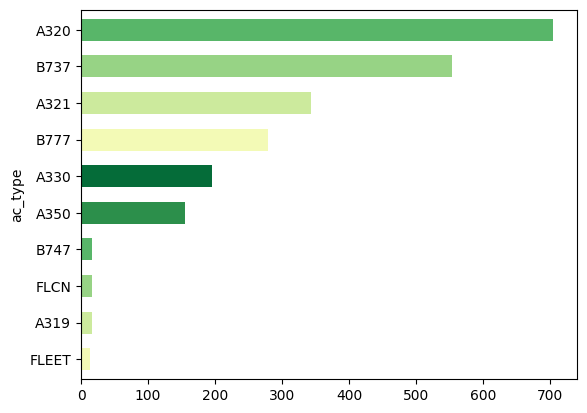

In [ ]:
#количество запросов по типам ВС
fig = plt.figure()
colors = sns.color_palette(palette='YlGn')

x = data.groupby('ac_type')['project_id'].agg('count').sort_values(ascending=True).tail(10)

ax = x.plot(kind='barh', width=0.6, color=colors)
#ax1.title.set_text('Общее количество заведений по категориям')
#ax1.title.set_size(20)
#ax1.set_xlabel('Количество заведений', size=(15))
#ax1.set_ylabel('Категории', size=(15))


#ax2 = data.groupby('ac_type').size().plot(kind='pie', autopct = '%1.1f%%', colors=colors)
#ax2.title.set_text('Доли заведений различных категорий')
#ax2.title.set_size(20)
#ax2.set_ylabel('')

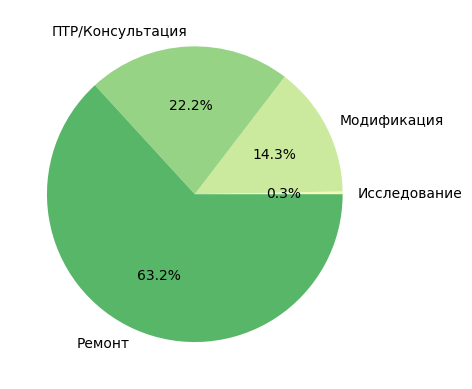

In [ ]:
#доли запросов по типу
ax1 = data.groupby('req_type').size().plot(kind='pie', autopct = '%1.1f%%',colors=colors)

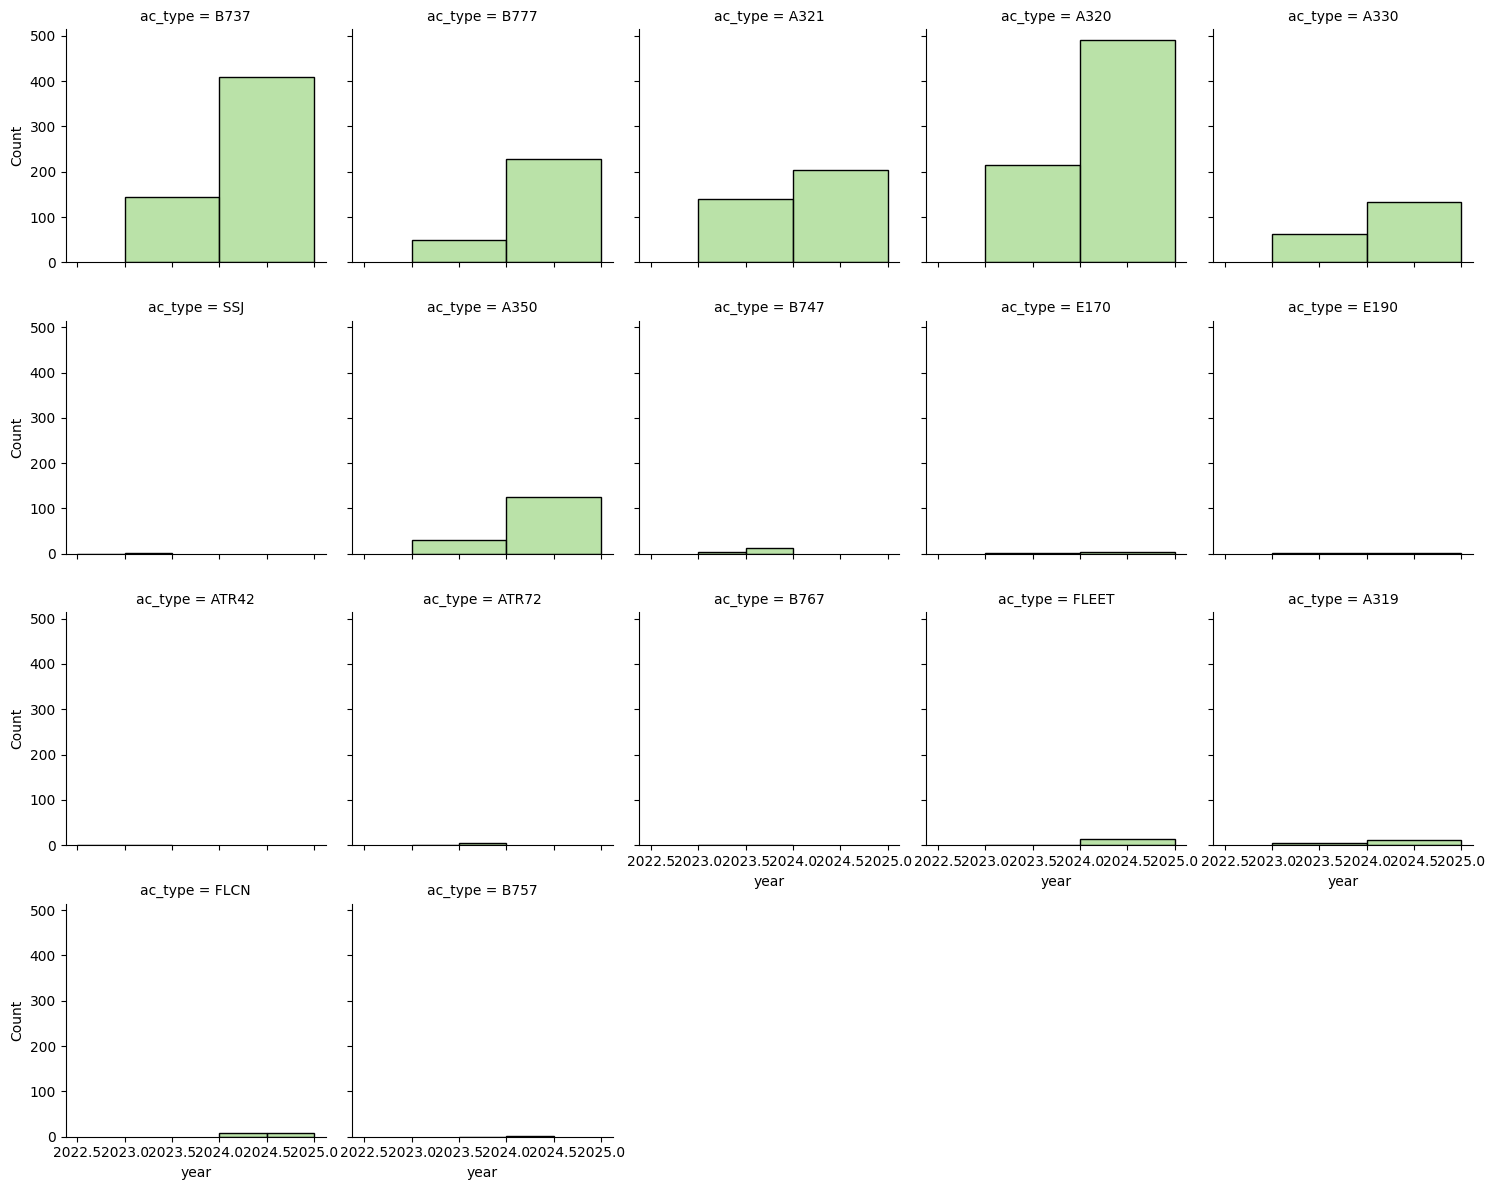

In [ ]:
grid = sns.FacetGrid(data, col='ac_type', col_wrap=5)
grid.map(sns.histplot, 'year', bins=2, color='#A3D98B')

<Axes: >

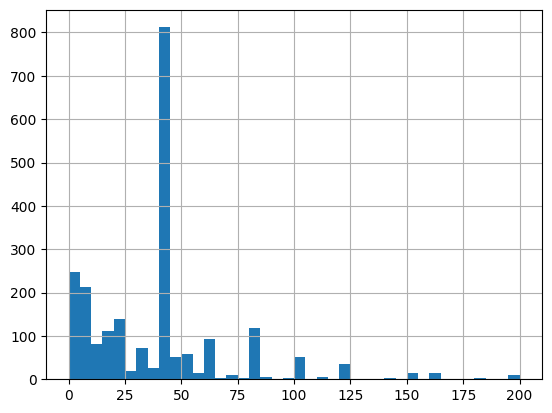

In [ ]:
#гистограмма фактических часов
data.hours_fact.hist(bins=40, range=(0, 200))

In [ ]:
data.query('hours_fact > 500.0')

,project_id,rev,dept,ac_type,regN,req_type,urgency,status,SE,date_in,...,hours_plan,hours_fact,supp,complete_date,requested_date,se_id,ac_id,postpone,year,month
290,АФ-23-0818М,0,NaN,B737,RA-73360,Модификация,Routine (>5 days),Завершен,Семенов Д,2023-09-08,...,1900.00,1500.00,NaN,2024-03-05,2023-09-29,3,79,158 days,2023,9
448,АФ-23-1025М,0,NaN,B777,MULTI,Модификация,Routine (>5 days),Завершен,Работнев А,2023-10-16,...,160.00,999.00,AIPC; CMM,2024-04-16,2024-03-29,15,0,18 days,2023,10
843,АФ-24-0686М,0,NaN,B737,MULTI,Модификация,Routine (>5 days),Завершен,Наумов М,2024-05-31,...,2000.00,1324.00,NaN,2024-11-22,2024-06-28,7,0,147 days,2024,5
889,АФ-24-0194М,0,NaN,A320,MULTI,Модификация,Routine (>5 days),Завершен,Наумов М,2024-02-14,...,5500.00,3100.00,AIPC,2024-10-21,2024-03-21,7,0,214 days,2024,2
1374,АФ-24-0800К,0,Отдел по вопросам конструкции,B737,RA-73112,ПТР/Консультация,Routine (>5 days),Завершен,Сидоров Д; Кунец А; Святский А,2024-07-06,...,400.00,1500.00,NaN,2025-03-18,2024-07-09,58,54,252 days,2024,7
1386,АФ-24-0816М,0,ОМиПИФ,A320,MULTI,Модификация,Routine (>5 days),Завершен,Наумов М,2024-07-11,...,400.00,3225.00,AIPC,2025-06-10,2024-12-31,7,0,161 days,2024,7
1387,АФ-24-0817М,0,ОМиПИФ,A320,MULTI,Модификация,Routine (>5 days),Завершен,Наумов М,2024-07-11,...,2000.00,4502.00,AIPC,2024-12-28,2024-12-31,7,0,-3 days,2024,7
1746,АФ-24-1293М,0,ОМиПИФ,B777,MULTI,Модификация,Routine (>5 days),Завершен,Семенов Д; Шатров С,2024-11-01,...,600.00,600.00,NaN,2025-06-06,2025-01-01,68,0,156 days,2024,11


In [ ]:
#затраченные часы по статусам
data.groupby('status')['hours_fact'].sum()

,hours_fact
status,
Завершен,106285.00
Отменен,3321.00
Сертификация,80.00
Утвержден,722.00


<Axes: xlabel='date_in', ylabel='hours_fact'>

<Figure size 2000x600 with 0 Axes>

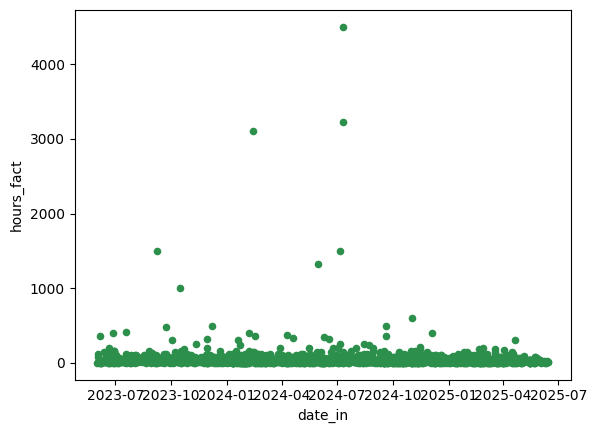

In [ ]:
#затраченные часы по годам
fig = plt.figure(figsize=(20, 6))
data.plot(kind='scatter', x='date_in', y='hours_fact', s=20, color='#2C8F4B')
#plt.title("Общие продажи игр по годам выпуска", fontsize=12)
#plt.xlabel('год издания', fontsize=10)
#plt.ylabel('продажи', fontsize=10);